# Simulação de Fila M/M/1

**Parâmetros:** λ = 9 clientes/s · μ = 10 clientes/s · ρ = λ/μ = 0,9

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho}, \quad \rho = \frac{\lambda}{\mu}$$

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Parâmetros ────────────────────────────────────────────────────────────────
LAM        = 9.0        # taxa de chegada  λ
MU         = 10.0       # taxa de serviço  μ
Z95        = 1.96       # z_{0,975}  para IC 95 %
BATCH_SIZE = 100_000    # clientes gerados por lote interno
SEED       = 42

def theoretical_mean(lam=LAM, mu=MU):
    """E[X] = ρ·(1/μ)/(1−ρ)"""
    rho = lam / mu
    return rho / (mu * (1.0 - rho))

print(f"E[X] teórico = {theoretical_mean():.6f} s")

E[X] teórico = 0.900000 s


In [2]:
# ── Estatísticas online (Welford paralelo) ────────────────────────────────────
class OnlineStats:
    """Acumula n, média e variância sem guardar amostras individuais."""
    __slots__ = ("n", "_mean", "_M2")

    def __init__(self):
        self.n, self._mean, self._M2 = 0, 0.0, 0.0

    def add_batch(self, xs: np.ndarray):
        n_b    = len(xs)
        mean_b = float(xs.mean())
        M2_b   = float(((xs - mean_b) ** 2).sum())
        if self.n == 0:
            self.n, self._mean, self._M2 = n_b, mean_b, M2_b
        else:
            n_new       = self.n + n_b
            delta       = mean_b - self._mean
            self._mean += delta * n_b / n_new
            self._M2   += M2_b + delta**2 * self.n * n_b / n_new
            self.n      = n_new

    @property
    def mean(self):     return self._mean

    @property
    def variance(self): return self._M2 / (self.n - 1) if self.n > 1 else float("inf")

    def half_width(self):
        """H = 1,96 · s / √n"""
        return Z95 * (self.variance / self.n) ** 0.5 if self.n > 1 else float("inf")


# ── Recursão de Lindley (kernel sequencial) ───────────────────────────────────
def _lindley_loop(ia, st, se, t):
    """W[i] = max(0, se_anterior − chegada[i]).  Retorna (waits, se, t)."""
    n = len(ia)
    waiting = [0.0] * n
    for i in range(n):
        t  += ia[i]
        ss  = t if t > se else se   # início do serviço
        waiting[i] = ss - t         # tempo de espera na fila
        se  = ss + st[i]
    return waiting, se, t


# ── Simulador M/M/1 ───────────────────────────────────────────────────────────
class MM1Queue:
    def __init__(self, lam=LAM, mu=MU, seed=None):
        self.lam = lam
        self.mu  = mu
        self.rng = np.random.default_rng(seed)
        self._reset()

    def _reset(self):
        self._se   = 0.0
        self._t    = 0.0
        self.stats = OnlineStats()

    def _step(self, size):
        ia = self.rng.exponential(1.0 / self.lam, size).tolist()
        st = self.rng.exponential(1.0 / self.mu,  size).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        self.stats.add_batch(np.array(waiting, dtype=np.float64))

    # Exercício 1
    def run_fixed(self, n):
        """Simula exatamente n clientes. Retorna (média, H)."""
        self._reset()
        done = 0
        while done < n:
            self._step(min(BATCH_SIZE, n - done))
            done = self.stats.n
        return self.stats.mean, self.stats.half_width()

    # Exercício 2
    def run_chow_robbins(self, d, min_n=0):
        """Para quando H ≤ d (largura IC ≤ 2d). Retorna (n, média, H)."""
        self._reset()
        while True:
            self._step(BATCH_SIZE)
            if self.stats.n >= min_n and self.stats.half_width() <= d:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width()

    # Exercício 3
    def run_relative_ci(self, gamma=0.05, min_n=1_000):
        """Para quando H / X̄ ≤ γ. Retorna (n, média, H)."""
        self._reset()
        while True:
            self._step(BATCH_SIZE)
            s = self.stats
            if s.n >= min_n and s.mean > 0 and s.half_width() / s.mean <= gamma:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width()

---
## Exercício 1 — Simulação com n fixo

Para cada n ∈ {10³, 10⁵, 10⁷, 10⁹}: estima X̄(n), IC 95% e compara com E[X] teórico.

In [3]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

ns      = [10**k for k in (3, 5, 7, 9)]
means   = []
halves  = []
rows    = []

for n in ns:
    t0 = time.perf_counter()
    mean, H = sim.run_fixed(n)
    elapsed = time.perf_counter() - t0
    means.append(mean)
    halves.append(H)
    rows.append((n, mean, mean - H, mean + H, H, abs(mean - E), elapsed))

# ── tabela ────────────────────────────────────────────────────────────────────
W = 13
header = (f"{'n':>{W}} | {'X̄(n)':>{W}} | {'IC inferior':>{W}} |"
          f" {'IC superior':>{W}} | {'H':>{W}} | {'|X̄ − E[X]|':>{W}} | {'tempo':>9}")
print(f"E[X] teórico = {E:.6f} s\n")
print(header)
print("─" * len(header))
for n, mean, lo, hi, H, err, t in rows:
    print(f"{n:{W},} | {mean:{W}.6f} | {lo:{W}.6f} | {hi:{W}.6f} | {H:{W}.6f} | {err:{W}.6f} | {t:>8.2f}s")

E[X] teórico = 0.900000 s

            n |         X̄(n) |   IC inferior |   IC superior |             H |   |X̄ − E[X]| |     tempo
─────────────────────────────────────────────────────────────────────────────────────────────────────────
        1,000 |      0.749988 |      0.700620 |      0.799355 |      0.049367 |      0.150012 |     0.00s
      100,000 |      0.803952 |      0.798440 |      0.809465 |      0.005513 |      0.096048 |     0.02s
   10,000,000 |      0.900531 |      0.899913 |      0.901148 |      0.000618 |      0.000531 |     1.29s
1,000,000,000 |      0.899918 |      0.899856 |      0.899979 |      0.000062 |      0.000082 |   147.06s


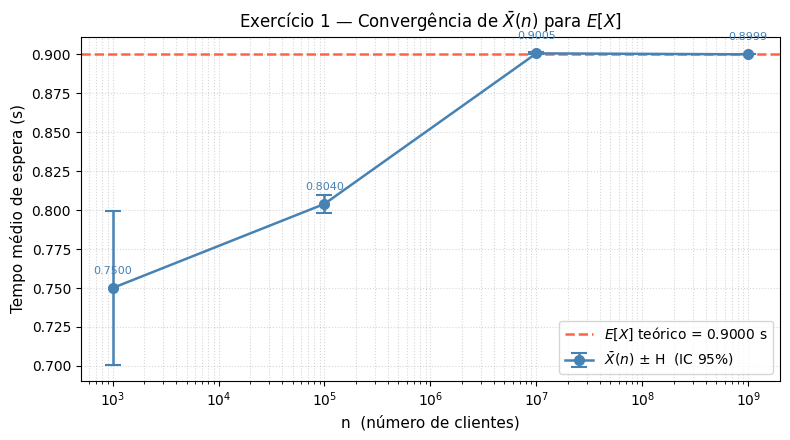

In [4]:
# ── gráfico: convergência de X̄(n) para E[X] ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

means_arr  = np.array(means)
halves_arr = np.array(halves)

ax.errorbar(
    ns, means_arr,
    yerr=halves_arr,
    fmt="o-", color="steelblue", capsize=6, capthick=1.5,
    linewidth=1.8, markersize=7, label=r"$\bar{X}(n)$ ± H  (IC 95%)"
)

ax.axhline(E, color="tomato", linewidth=1.8, linestyle="--",
           label=rf"$E[X]$ teórico = {E:.4f} s")

# anotações com o valor de X̄ em cada ponto
for n, m, h in zip(ns, means_arr, halves_arr):
    ax.annotate(f"{m:.4f}", xy=(n, m), xytext=(0, 10),
                textcoords="offset points", ha="center", fontsize=8, color="steelblue")

ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: rf"$10^{{{int(round(np.log10(x)))}}}$"
))
ax.set_xlabel("n  (número de clientes)", fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title("Exercício 1 — Convergência de $\\bar{X}(n)$ para $E[X]$", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()

---
## Exercício 2 — Regra de parada de Chow e Robbins

Simulação para até o intervalo de confiança atingir largura ≤ 2d.
Valores de d: 1,0 · 0,5 · 0,1 · 0,05.

In [5]:
E   = theoretical_mean()
sim = MM1Queue(seed=SEED)
ds  = [1.0, 0.5, 0.1, 0.05]

W   = 14
header = (f"{'d':>8} | {'n final':>{W}} | {'X̄(n)':>12} |"
          f" {'H':>12} | {'2d':>8} | {'H ≤ d?':>7} | {'tempo':>9}")
print(f"E[X] teórico = {E:.6f} s\n")
print(header)
print("─" * len(header))

for d in ds:
    t0 = time.perf_counter()
    n, mean, H = sim.run_chow_robbins(d)
    elapsed = time.perf_counter() - t0
    ok = "✓" if H <= d else "✗"
    print(f"{d:>8.2f} | {n:{W},} | {mean:>12.6f} | {H:>12.6f} | {2*d:>8.4f} | {ok:>7} | {elapsed:>8.2f}s")

E[X] teórico = 0.900000 s

       d |        n final |        X̄(n) |            H |       2d |  H ≤ d? |     tempo
────────────────────────────────────────────────────────────────────────────────────────
    1.00 |        100,000 |     0.804918 |     0.005525 |   2.0000 |       ✓ |     0.02s
    0.50 |        100,000 |     0.983532 |     0.006839 |   1.0000 |       ✓ |     0.02s
    0.10 |        100,000 |     1.002159 |     0.006948 |   0.2000 |       ✓ |     0.01s
    0.05 |        100,000 |     0.878699 |     0.005701 |   0.1000 |       ✓ |     0.01s


---
## Exercício 3 — Regra de parada por tamanho relativo do IC

Para quando H / X̄ ≤ γ = 5 %.

In [6]:
E   = theoretical_mean()
sim = MM1Queue(seed=SEED)

t0 = time.perf_counter()
n, mean, H = sim.run_relative_ci(gamma=0.05)
elapsed = time.perf_counter() - t0

lo, hi = mean - H, mean + H

print(f"  n final    = {n:,}")
print(f"  X̄(n)      = {mean:.6f} s")
print(f"  H          = {H:.6f} s")
print(f"  H / X̄     = {H/mean:.4%}   (critério: ≤ 5 %)")
print(f"  IC 95%     = [ {lo:.6f} ,  {hi:.6f} ]")
print(f"  E[X] teór. = {E:.6f} s")
print(f"  tempo      = {elapsed:.2f} s")

  n final    = 100,000
  X̄(n)      = 0.804918 s
  H          = 0.005525 s
  H / X̄     = 0.6864%   (critério: ≤ 5 %)
  IC 95%     = [ 0.799393 ,  0.810444 ]
  E[X] teór. = 0.900000 s
  tempo      = 0.02 s
